In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print(df.info())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [6]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [7]:
num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')

df[num_cols] = imputer.fit_transform(df[num_cols])

In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


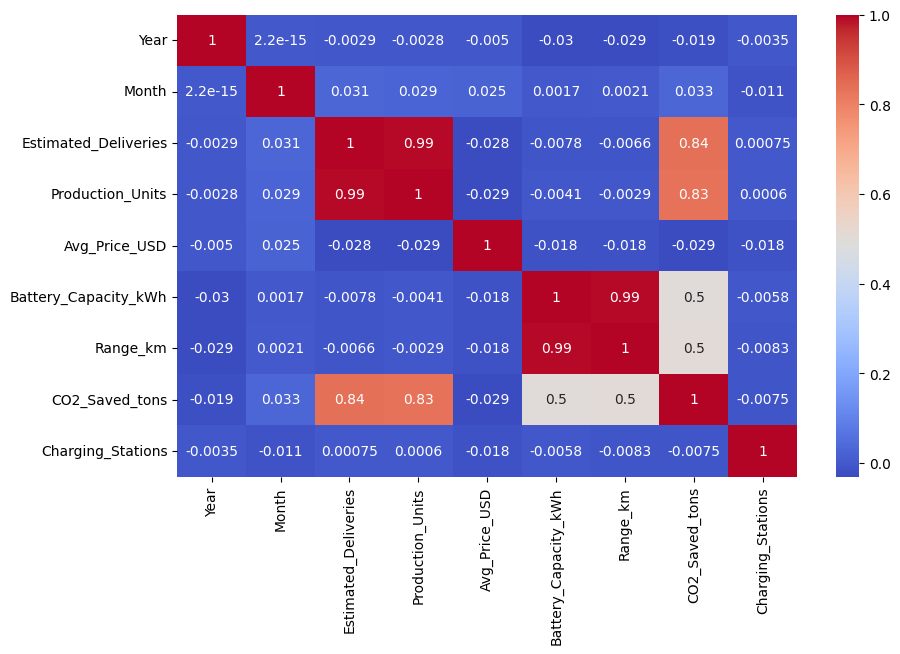

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [10]:
print(df.columns)


Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


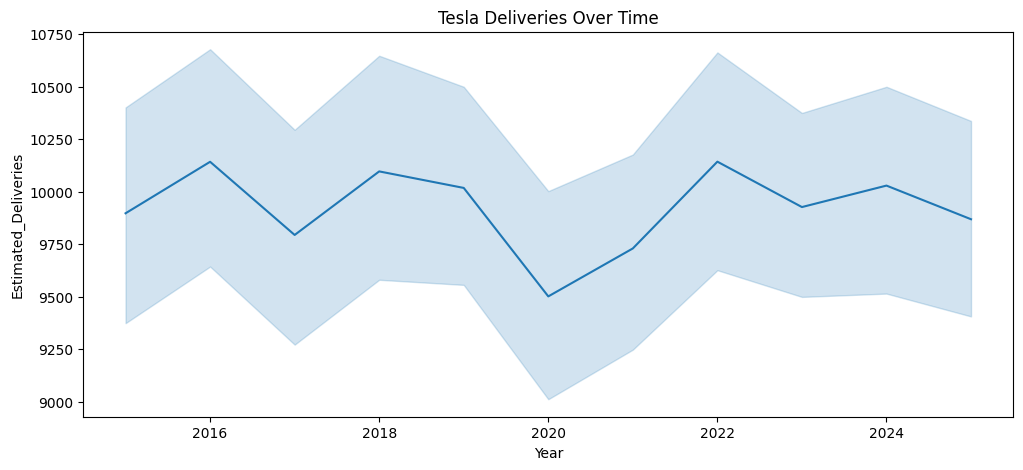

In [11]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Year',
             y='Estimated_Deliveries',
             data=df)

plt.title("Tesla Deliveries Over Time")
plt.show()

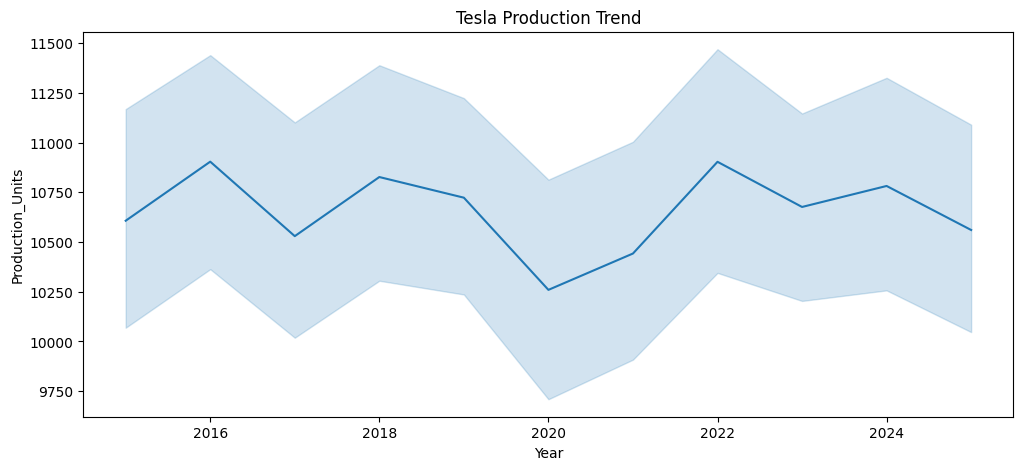

In [12]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x='Year',
    y='Production_Units'
)

plt.title("Tesla Production Trend")
plt.show()

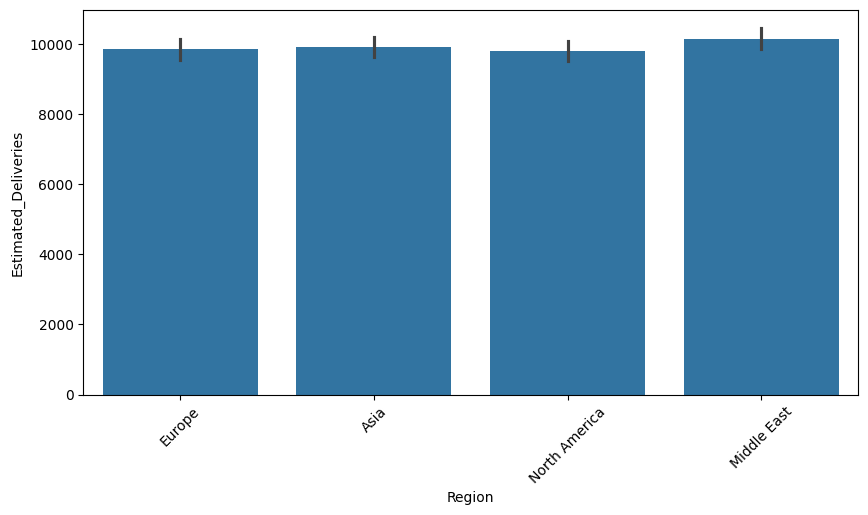

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries'
)

plt.xticks(rotation=45)
plt.show()

In [14]:
df['Delivery_Growth'] = (
    df['Estimated_Deliveries'].pct_change() * 100
)

df['Production_Growth'] = (
    df['Production_Units'].pct_change() * 100
)

df['Efficiency'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)

df.fillna(0, inplace=True)

In [15]:
encoder = LabelEncoder()

for col in ['Region', 'Model', 'Source_Type']:
    df[col] = encoder.fit_transform(df[col])

In [16]:
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [20]:
print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R²:",
      r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 110.2929192255791
RMSE: 155.53679218412518
R²: 0.998377081302485


In [21]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R²:",
      r2_score(y_test, rf_pred))

Random Forest Results
MAE: 67.39426136363633
RMSE: 112.21220591473097
R²: 0.9991552840624569


In [22]:
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15], 'n_estimators': [100, 200]},
             scoring='r2')

In [23]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'n_estimators': 200}


In [24]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Best Model R²:",
      r2_score(y_test, best_pred))

Best Model R²: 0.9991109773336092


In [25]:
importance = best_model.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df)

                 Feature  Importance
4       Production_Units    0.990383
13            Efficiency    0.008652
8         CO2_Saved_tons    0.000209
5          Avg_Price_USD    0.000121
1                  Month    0.000097
10     Charging_Stations    0.000095
7               Range_km    0.000088
0                   Year    0.000081
11       Delivery_Growth    0.000067
12     Production_Growth    0.000062
3                  Model    0.000049
2                 Region    0.000041
9            Source_Type    0.000031
6   Battery_Capacity_kWh    0.000023


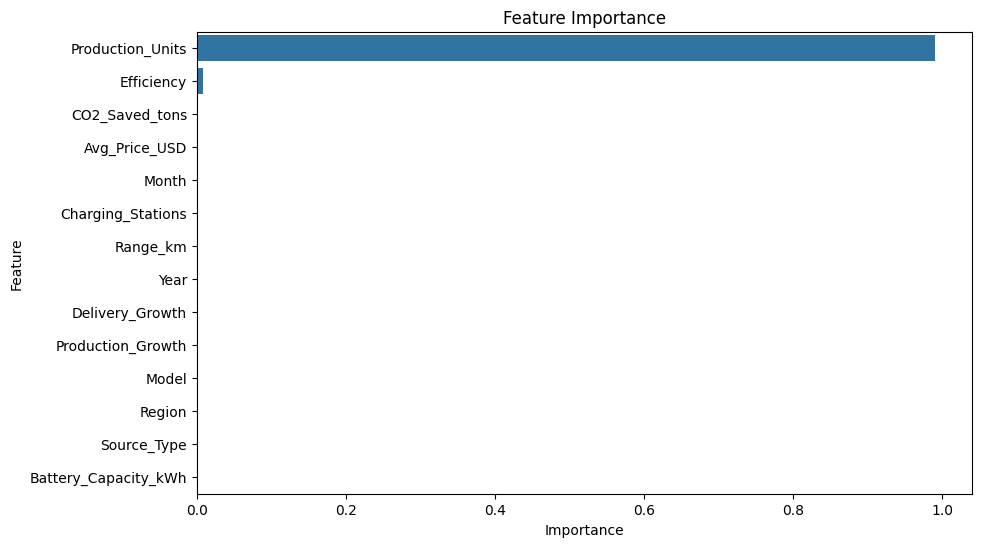

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_df,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [28]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [31]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(int).astype(str) + '-' +
    df['Month'].astype(int).astype(str) + '-01',
    format='%Y-%m-%d'
)
print(df[['Year', 'Month', 'Date']].head())

     Year  Month       Date
0  2023.0    5.0 2023-05-01
1  2015.0    2.0 2015-02-01
2  2019.0    1.0 2019-01-01
3  2021.0    2.0 2021-02-01
4  2016.0   12.0 2016-12-01


In [34]:
forecast_df = df[['Date',
                  'Estimated_Deliveries']]

forecast_df.columns = ['ds','y']

In [35]:
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)

16:38:20 - cmdstanpy - INFO - Chain [1] start processing
16:38:20 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
future = model.make_future_dataframe(
    periods=12,
    freq='ME'
)

In [38]:
forecast = model.predict(future)

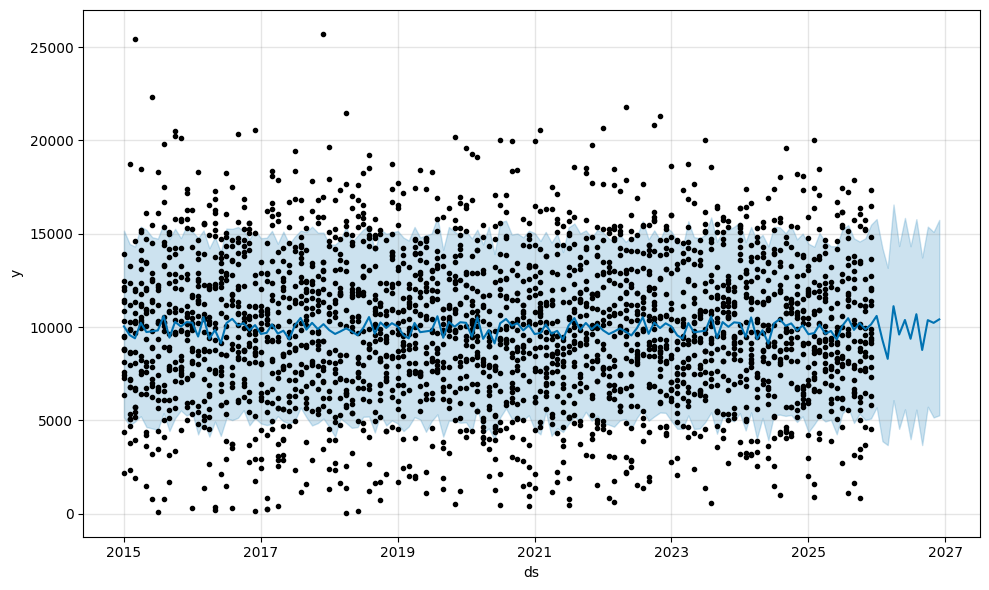

In [39]:
fig = model.plot(forecast)
plt.show()